# Dominican Film Industry — CIPAC Resolutions EDA

**Author:** Jorge Doiany Peguero Almonte  
**GitHub:** [jorgedoiany](https://github.com/jorgedoiany)  
**Dataset:** Supabase — `cipac_resolutions`  
**Period:** 2012–2026  
**Last updated:** August 2026  

---

## Overview

This notebook presents an exploratory data analysis (EDA) of the CIPAC investment and expense validation resolutions issued by the **Dominican Film Commission** ([DGCINE](https://dgcine.gob.do)) between 2012 and 2026. These resolutions correspond to cinematographic projects that benefit from the tax incentives established under **Law 108-10 for the Promotion of Cinematographic Activity in the Dominican Republic**.

The goal is to uncover patterns and trends in film investment, tax credits, production budgets, and key industry players (investors and production companies).

This analysis serves as the foundation for the **Dominican Film Industry Executive Dashboard**, built with Python and Streamlit.

---

## Key Concepts

**Law 108-10** — Dominican Republic's Film Promotion Law, which establishes tax incentives for local and foreign film productions.

**DGCINE** — Dirección General de Cine (Dominican Film Commission). The government body responsible for regulating and promoting the Dominican film industry.

**CIPAC** — Consejo Intersectorial para la Promoción de la Actividad Cinematográfica. The council that reviews and approves investment and expense validation requests.

**Art. 34 — Investment Validation (Validación de Inversión)**  
Applies to Dominican productions. Local investors (companies or individuals) who fund a Dominican film can receive a tax credit equivalent to 100% of their validated investment, applicable against their income tax (ISR). The production must hold a CPND certificate.

**Art. 39 — Expense Validation (Validación de Gastos)**  
Applies to foreign productions filming in the Dominican Republic. Foreign producers can receive a transferable tax credit equivalent to 25% of their validated expenses in the country, provided that the total expenses incurred at the time of the request are equal to or greater than USD 500,000.

**CIPAC Resolution** — The official document issued by CIPAC that validates an investment (Art. 34) or expense (Art. 39) and authorizes the corresponding tax credit. Each resolution corresponds to one investor or production company per project. A single film can have multiple resolutions if it has multiple investors.

**CPND** — Certificado de Nacionalidad Dominicana. Certificate issued to Dominican productions before filming begins, required for Art. 34 incentives.

**PUR** — Permiso Único de Rodaje. Filming permit required for all productions (both Dominican and foreign) before filming begins.

**Tax Credit** — A reduction in taxes owed, not a cash payment. Under Art. 34, the credit equals 100% of the validated investment. Under Art. 39, it equals 25% of validated expenses in the DR.

---

## Dataset Variables

| Variable | Description |
|---|---|
| `year` | Year the resolution was issued |
| `incentive_article` | Incentive type: `art_34` (Dominican) or `art_39` (Foreign) |
| `resolution_type` | Outcome: `approved` or `rejected` |
| `investor_name` | Name of the local investor (Art. 34 only) |
| `investor_rnc` | Tax ID (RNC) of the investor (Art. 34 only) |
| `local_company` | Dominican production company representing the project |
| `producer_rnc` | Tax ID (RNC) of the production company |
| `film_title` | Title of the cinematographic work |
| `pur_number` | Filming permit number (Permiso Único de Rodaje) |
| `cpnd_number` | Dominican nationality certificate number (Art. 34 only) |
| `request_date` | Date the validation request was submitted |
| `resolution_date` | Date the resolution was issued |
| `validated_amount_dop` | Total validated investment or expenses in DOP |
| `tax_credit_dop` | Tax credit authorized in DOP |
| `tax_credit_pct` | Tax credit percentage (100% for Art. 34, 25% for Art. 39) |
| `total_budget_approved` | Total production budget approved in the CPND/PUR |
| `total_budget_executed` | Total production budget actually executed |

---

> **Important note:** One resolution does not equal one film. A single film can have multiple resolutions across different years — one per investor (Art. 34) or one per validation request (Art. 39). Therefore, the number of resolutions reflects investment activity, not the number of unique productions.

---

### Data Completeness

CIPAC resolutions are official public documents that should be sequentially numbered and publicly available on the DGCINE website in compliance with Dominican transparency regulations. However, a manual review of resolution numbers identified **299 gaps** across all years:

- **229** resolution numbers returned a **404 error** on the DGCINE website at the time of data collection. This may indicate that these resolutions have not been published, were removed, or were never issued — which would represent a transparency concern.
- **70** resolutions exist on the website but were deliberately excluded by the scraper, as they correspond to other resolution types not relevant to this analysis (administrative, regulatory, cinema construction approvals, budget modifications, etc.).

The scraper was specifically designed to only download investment validation (Art. 34) and expense validation (Art. 39) resolutions, which are the only types relevant to the analysis of Law 108-10 tax incentives.

The complete list of the 229 resolution numbers that returned a 404 error is presented below for transparency and reproducibility.

|   Year | Resolution Number   |
|-------:|:--------------------|
|   2026 | CIPAC-2026-048      |
|   2026 | CIPAC-2026-089      |
|   2026 | CIPAC-2026-159      |
|   2026 | CIPAC-2026-160      |
|   2026 | CIPAC-2026-161      |
|   2026 | CIPAC-2026-184      |
|   2026 | CIPAC-2026-186      |
|   2026 | CIPAC-2026-189      |
|   2026 | CIPAC-2026-195      |
|   2025 | CIPAC-2025-001      |
|   2025 | CIPAC-2025-022      |
|   2025 | CIPAC-2025-027      |
|   2025 | CIPAC-2025-030      |
|   2025 | CIPAC-2025-110      |
|   2025 | CIPAC-2025-137      |
|   2025 | CIPAC-2025-143      |
|   2025 | CIPAC-2025-153      |
|   2025 | CIPAC-2025-162      |
|   2025 | CIPAC-2025-163      |
|   2025 | CIPAC-2025-175      |
|   2025 | CIPAC-2025-176      |
|   2024 | CIPAC-2024-010      |
|   2024 | CIPAC-2024-011      |
|   2024 | CIPAC-2024-021      |
|   2024 | CIPAC-2024-022      |
|   2024 | CIPAC-2024-023      |
|   2024 | CIPAC-2024-024      |
|   2024 | CIPAC-2024-025      |
|   2024 | CIPAC-2024-026      |
|   2024 | CIPAC-2024-027      |
|   2024 | CIPAC-2024-028      |
|   2024 | CIPAC-2024-029      |
|   2024 | CIPAC-2024-030      |
|   2024 | CIPAC-2024-031      |
|   2024 | CIPAC-2024-032      |
|   2024 | CIPAC-2024-033      |
|   2024 | CIPAC-2024-034      |
|   2024 | CIPAC-2024-035      |
|   2024 | CIPAC-2024-036      |
|   2024 | CIPAC-2024-037      |
|   2024 | CIPAC-2024-038      |
|   2024 | CIPAC-2024-039      |
|   2024 | CIPAC-2024-040      |
|   2024 | CIPAC-2024-041      |
|   2024 | CIPAC-2024-042      |
|   2024 | CIPAC-2024-043      |
|   2024 | CIPAC-2024-044      |
|   2024 | CIPAC-2024-045      |
|   2024 | CIPAC-2024-046      |
|   2024 | CIPAC-2024-047      |
|   2024 | CIPAC-2024-048      |
|   2024 | CIPAC-2024-049      |
|   2024 | CIPAC-2024-050      |
|   2024 | CIPAC-2024-051      |
|   2024 | CIPAC-2024-052      |
|   2024 | CIPAC-2024-053      |
|   2024 | CIPAC-2024-054      |
|   2024 | CIPAC-2024-055      |
|   2024 | CIPAC-2024-056      |
|   2024 | CIPAC-2024-057      |
|   2024 | CIPAC-2024-058      |
|   2024 | CIPAC-2024-076      |
|   2024 | CIPAC-2024-085      |
|   2024 | CIPAC-2024-087      |
|   2024 | CIPAC-2024-089      |
|   2024 | CIPAC-2024-091      |
|   2024 | CIPAC-2024-092      |
|   2024 | CIPAC-2024-093      |
|   2024 | CIPAC-2024-104      |
|   2024 | CIPAC-2024-106      |
|   2024 | CIPAC-2024-107      |
|   2024 | CIPAC-2024-108      |
|   2024 | CIPAC-2024-109      |
|   2024 | CIPAC-2024-110      |
|   2024 | CIPAC-2024-113      |
|   2024 | CIPAC-2024-114      |
|   2024 | CIPAC-2024-115      |
|   2024 | CIPAC-2024-116      |
|   2024 | CIPAC-2024-117      |
|   2024 | CIPAC-2024-118      |
|   2024 | CIPAC-2024-119      |
|   2024 | CIPAC-2024-120      |
|   2024 | CIPAC-2024-122      |
|   2024 | CIPAC-2024-124      |
|   2024 | CIPAC-2024-125      |
|   2024 | CIPAC-2024-130      |
|   2024 | CIPAC-2024-131      |
|   2024 | CIPAC-2024-133      |
|   2024 | CIPAC-2024-134      |
|   2024 | CIPAC-2024-135      |
|   2024 | CIPAC-2024-137      |
|   2024 | CIPAC-2024-138      |
|   2024 | CIPAC-2024-145      |
|   2024 | CIPAC-2024-149      |
|   2024 | CIPAC-2024-153      |
|   2024 | CIPAC-2024-158      |
|   2024 | CIPAC-2024-159      |
|   2024 | CIPAC-2024-160      |
|   2024 | CIPAC-2024-161      |
|   2024 | CIPAC-2024-162      |
|   2024 | CIPAC-2024-163      |
|   2024 | CIPAC-2024-164      |
|   2024 | CIPAC-2024-165      |
|   2024 | CIPAC-2024-166      |
|   2024 | CIPAC-2024-167      |
|   2024 | CIPAC-2024-168      |
|   2024 | CIPAC-2024-169      |
|   2024 | CIPAC-2024-170      |
|   2024 | CIPAC-2024-171      |
|   2024 | CIPAC-2024-172      |
|   2024 | CIPAC-2024-173      |
|   2024 | CIPAC-2024-174      |
|   2024 | CIPAC-2024-175      |
|   2024 | CIPAC-2024-176      |
|   2024 | CIPAC-2024-177      |
|   2024 | CIPAC-2024-178      |
|   2024 | CIPAC-2024-179      |
|   2024 | CIPAC-2024-180      |
|   2024 | CIPAC-2024-181      |
|   2024 | CIPAC-2024-182      |
|   2024 | CIPAC-2024-183      |
|   2024 | CIPAC-2024-184      |
|   2024 | CIPAC-2024-185      |
|   2024 | CIPAC-2024-186      |
|   2024 | CIPAC-2024-187      |
|   2024 | CIPAC-2024-188      |
|   2024 | CIPAC-2024-189      |
|   2024 | CIPAC-2024-190      |
|   2024 | CIPAC-2024-191      |
|   2024 | CIPAC-2024-192      |
|   2024 | CIPAC-2024-193      |
|   2024 | CIPAC-2024-194      |
|   2024 | CIPAC-2024-195      |
|   2024 | CIPAC-2024-196      |
|   2024 | CIPAC-2024-197      |
|   2024 | CIPAC-2024-198      |
|   2024 | CIPAC-2024-199      |
|   2024 | CIPAC-2024-200      |
|   2024 | CIPAC-2024-201      |
|   2024 | CIPAC-2024-202      |
|   2024 | CIPAC-2024-203      |
|   2024 | CIPAC-2024-204      |
|   2024 | CIPAC-2024-205      |
|   2024 | CIPAC-2024-208      |
|   2024 | CIPAC-2024-209      |
|   2024 | CIPAC-2024-212      |
|   2024 | CIPAC-2024-260      |
|   2024 | CIPAC-2024-261      |
|   2024 | CIPAC-2024-262      |
|   2024 | CIPAC-2024-263      |
|   2024 | CIPAC-2024-264      |
|   2024 | CIPAC-2024-265      |
|   2024 | CIPAC-2024-266      |
|   2024 | CIPAC-2024-267      |
|   2024 | CIPAC-2024-268      |
|   2024 | CIPAC-2024-269      |
|   2024 | CIPAC-2024-270      |
|   2024 | CIPAC-2024-285      |
|   2024 | CIPAC-2024-286      |
|   2024 | CIPAC-2024-302      |
|   2024 | CIPAC-2024-303      |
|   2024 | CIPAC-2024-304      |
|   2024 | CIPAC-2024-305      |
|   2024 | CIPAC-2024-306      |
|   2024 | CIPAC-2024-307      |
|   2024 | CIPAC-2024-308      |
|   2024 | CIPAC-2024-309      |
|   2024 | CIPAC-2024-310      |
|   2024 | CIPAC-2024-311      |
|   2024 | CIPAC-2024-312      |
|   2024 | CIPAC-2024-313      |
|   2024 | CIPAC-2024-314      |
|   2024 | CIPAC-2024-315      |
|   2024 | CIPAC-2024-316      |
|   2024 | CIPAC-2024-317      |
|   2024 | CIPAC-2024-318      |
|   2023 | CIPAC-2023-112      |
|   2023 | CIPAC-2023-211      |
|   2023 | CIPAC-2023-212      |
|   2023 | CIPAC-2023-213      |
|   2023 | CIPAC-2023-214      |
|   2023 | CIPAC-2023-215      |
|   2023 | CIPAC-2023-216      |
|   2023 | CIPAC-2023-217      |
|   2023 | CIPAC-2023-218      |
|   2023 | CIPAC-2023-236      |
|   2023 | CIPAC-2023-237      |
|   2023 | CIPAC-2023-275      |
|   2023 | CIPAC-2023-302      |
|   2023 | CIPAC-2023-325      |
|   2022 | CIPAC-2022-012      |
|   2022 | CIPAC-2022-026      |
|   2022 | CIPAC-2022-030      |
|   2022 | CIPAC-2022-038      |
|   2022 | CIPAC-2022-039      |
|   2022 | CIPAC-2022-053      |
|   2022 | CIPAC-2022-054      |
|   2022 | CIPAC-2022-055      |
|   2022 | CIPAC-2022-061      |
|   2022 | CIPAC-2022-062      |
|   2022 | CIPAC-2022-067      |
|   2022 | CIPAC-2022-168      |
|   2022 | CIPAC-2022-185      |
|   2022 | CIPAC-2022-186      |
|   2022 | CIPAC-2022-187      |
|   2022 | CIPAC-2022-188      |
|   2022 | CIPAC-2022-189      |
|   2022 | CIPAC-2022-190      |
|   2022 | CIPAC-2022-191      |
|   2022 | CIPAC-2022-192      |
|   2022 | CIPAC-2022-193      |
|   2022 | CIPAC-2022-197      |
|   2020 | CIPAC-2020-027      |
|   2020 | CIPAC-2020-028      |
|   2020 | CIPAC-2020-029      |
|   2020 | CIPAC-2020-201      |
|   2018 | CIPAC-2018-050      |
|   2018 | CIPAC-2018-231      |
|   2018 | CIPAC-2018-232      |
|   2018 | CIPAC-2018-233      |
|   2018 | CIPAC-2018-234      |
|   2018 | CIPAC-2018-235      |
|   2018 | CIPAC-2018-236      |
|   2017 | CIPAC-2017-120      |
|   2017 | CIPAC-2017-121      |
|   2015 | CIPAC-2015-123      |
|   2013 | CIPAC-2013-013      |
|   2013 | CIPAC-2013-034      |
|   2013 | CIPAC-2013-041      |

---

## Table of Contents
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Dataset Overview](#2-dataset-overview)
3. [Data Quality Analysis](#3-data-quality-analysis)
4. [Outlier Analysis](#4-outlier-analysis)
5. [Resolutions by Year](#5-resolutions-by-year)
6. [Art. 34 vs Art. 39](#6-art-34-vs-art-39)
7. [Top Art. 34 Investors](#7-top-art-34-investors)
8. [Top Art. 34 Production Companies](#8-top-art-34-production-companies)
9. [Top Art. 39 Production Companies](#9-top-art-39-production-companies)
10. [Film Analysis](#10-film-analysis)
10. [Validated Amounts & Tax Credits](#11-validated-amounts--tax-credits)
11. [Correlation Analysis](#12-correlation-analysis)
12. [Budget Analysis (Approved vs Executed)](#13-budget-analysis-approved-vs-executed)
13. [Key Findings & Conclusions](#14-key-findings--conclusions)

## 1. Setup & Data Loading

In [1]:
# --- Standard libraries ---
import pandas as pd
import numpy as np
import os
import sys

# --- Visualization ---
import matplotlib.pyplot as plt
from matplotlib import ticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# --- Database ---
from sqlalchemy import create_engine
from dotenv import load_dotenv

# --- Display settings ---
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# --- Plot style ---
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [2]:
# Load dataset from CSV or Supabase
if os.path.exists('../data/cipac_resolutions.csv'):
    df = pd.read_csv('../data/cipac_resolutions.csv', dtype={'year': str})
    print(f"Dataset loaded from CSV: {df.shape[0]} rows x {df.shape[1]} columns")
else:
    load_dotenv()
    engine = create_engine(os.getenv('SUPABASE_DB_URL') or '')
    df = pd.read_sql("""
        SELECT
            resolution_number, year, incentive_article, resolution_type,
            investor_name, investor_rnc, producer_rnc, film_title,
            local_company, pur_number, cpnd_number, request_date,
            resolution_date, validated_amount_dop, tax_credit_dop,
            tax_credit_pct, total_budget_approved, total_budget_executed
        FROM cipac_resolutions
        ORDER BY year, resolution_number
    """, engine)
    print(f"Dataset loaded from Supabase: {df.shape[0]} rows x {df.shape[1]} columns")

df.head(10)

Dataset loaded from CSV: 2543 rows x 18 columns


,resolution_number,year,incentive_article,resolution_type,investor_name,investor_rnc,producer_rnc,film_title,local_company,pur_number,cpnd_number,request_date,resolution_date,validated_amount_dop,tax_credit_dop,tax_credit_pct,total_budget_approved,total_budget_executed
0,CIPAC-2012-001,2012,art_39,approved,NaN,NaN,1-30-83426-1,THE TRUTH,"FILM001, INC",2.00,NaN,2012-02-29,2012-03-29,46168271.82,11542067.96,25.00,38432098.00,46168271.82
1,CIPAC-2012-002,2012,art_34,approved,"VIDEO UNIVERSAL, S.R.L.",1-22-00857-8,1-30-82560-2,EL REY DE NAJAYO,"ENTREPRENEUR FILMS, S.R.L.",1.00,1.00,2012-03-23,2012-03-29,990000.00,990000.00,100.00,14240247.18,14240247.00
2,CIPAC-2012-003,2012,art_34,approved,"RSD REMANUFACTURE SOLUTIONS DOMINICANA, S.R.L.",1-30-23890-1,1-30-82560-2,EL REY DE NAJAYO,"ENTREPRENEUR FILMS, S.R.L.",1.00,1.00,2012-03-23,2012-03-29,990000.00,990000.00,100.00,14240247.18,14240247.00
3,CIPAC-2012-004,2012,art_34,approved,SERVICIOS INFORMATIVOS NACIONALES NOTICIAS SIN...,1-30-17966-2,1-30-82560-2,EL REY DE NAJAYO,"ENTREPRENEUR FILMS, S.R.L.",1.00,1.00,2012-03-23,2012-03-29,1073142.97,1073142.97,100.00,14240247.18,14240247.00
4,CIPAC-2012-005,2012,art_34,approved,"UNITED BRANDS, S.A.",1-24-01933-8,1-30-82560-2,EL REY DE NAJAYO,"ENTREPRENEUR FILMS, S.R.L.",1.00,1.00,2012-03-23,2012-03-29,8257892.64,8257892.64,100.00,14240247.18,14240247.00
5,CIPAC-2012-010,2012,art_34,approved,"ALTICE DOMINICANA, S.A.",1-01-61878-7,1-30-84607-3,LOTOMAN 2.0,"DRAGON FILMS, S.R.L.",10.00,2.00,2012-07-09,2012-07-19,20000000.00,20000000.00,100.00,46885882.50,51392492.71
6,CIPAC-2012-011,2012,art_34,approved,"AES ANDRES DR, S.A.",1-01-83722-5,1-30-84607-3,LOTOMAN 2.0,"DRAGON FILMS, S.R.L.",10.00,2.00,2012-07-09,2012-07-19,25000000.00,25000000.00,100.00,46885882.50,51392492.71
7,CIPAC-2012-012,2012,art_34,approved,"BANCO MÚLTIPLE BDI, S.A.",1-01-04029-7,1-30-86801-8,"FEO DE DÍA, LINDO DE NOCHE","CINDERELO, S.R.L.",7.00,4.00,2012-07-09,2012-07-19,3504473.00,3504473.00,100.00,29736672.00,10284540.00
8,CIPAC-2012-013,2012,art_34,approved,"CENTROS DEL CARIBE, S.A.S.",1-01-70451-9,1-30-86801-8,"FEO DE DÍA, LINDO DE NOCHE","CINDERELO, S.R.L.",7.00,4.00,2012-07-09,2012-07-19,3504473.00,3504473.00,100.00,29736672.00,10284540.00
9,CIPAC-2012-014,2012,art_34,approved,"ANTONIO CHAHAIN M, S.A.",1-01-08822-2,1-30-86801-8,"FEO DE DÍA, LINDO DE NOCHE","CINDERELO, S.R.L.",7.00,4.00,2012-07-09,2012-07-19,802405.51,802405.51,100.00,29736672.00,10284540.00


In [3]:
# Convert date columns
df['request_date'] = pd.to_datetime(df['request_date'])
df['resolution_date'] = pd.to_datetime(df['resolution_date'])

## 2. Dataset Overview

A quick look at the structure, data types, and basic statistics of the dataset.

In [4]:
print(f"Shape: {df.shape[0]} resolutions × {df.shape[1]} columns")
print(f"\nColumns:\n")
for col in df.columns:
    print(f"  - {col} ({df[col].dtype})")

Shape: 2543 resolutions × 18 columns

Columns:

  - resolution_number (str)
  - year (str)
  - incentive_article (str)
  - resolution_type (str)
  - investor_name (str)
  - investor_rnc (str)
  - producer_rnc (str)
  - film_title (str)
  - local_company (str)
  - pur_number (float64)
  - cpnd_number (float64)
  - request_date (datetime64[us])
  - resolution_date (datetime64[us])
  - validated_amount_dop (float64)
  - tax_credit_dop (float64)
  - tax_credit_pct (float64)
  - total_budget_approved (float64)
  - total_budget_executed (float64)


In [5]:
df.describe(include='all')

,resolution_number,year,incentive_article,resolution_type,investor_name,investor_rnc,producer_rnc,film_title,local_company,pur_number,cpnd_number,request_date,resolution_date,validated_amount_dop,tax_credit_dop,tax_credit_pct,total_budget_approved,total_budget_executed
count,2543,2543,2543,2543,2459,2459,2543,2543,2543,2542.00,2458.00,2539,2543,2543.00,2539.00,2543.00,2542.00,2541.00
unique,2543,15,2,2,496,493,367,665,372,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,CIPAC-2012-001,2023,art_34,approved,"CERVECERÍA NACIONAL DOMINICANA, S.A.",1-01-01063-2,1-30-99100-6,EL PODER DE LAS TINIEBLAS,"PILÓN PRODUCTIONS, S.R.L.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,330,2459,2539,86,88,59,29,59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,590.65,355.69,2020-07-27 13:05:30.366286,2020-08-24 13:07:06.110892,20731846.44,12151731.26,97.52,78272105.99,52448814.80
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,1.00,2012-02-29 00:00:00,2012-03-29 00:00:00,41153.14,41153.14,25.00,3160270.00,135000.00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,231.00,154.00,2017-08-25 00:00:00,2017-10-26 00:00:00,2000000.00,2000000.00,100.00,39553251.42,22800000.00
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,552.00,317.00,2020-12-21 00:00:00,2021-01-29 00:00:00,5000000.00,5000000.00,100.00,59957660.70,39984903.00
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,910.00,526.00,2023-10-25 00:00:00,2023-11-15 00:00:00,11232245.89,10887500.00,100.00,73957343.69,60912761.62
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2350.00,8351.00,2026-07-15 00:00:00,2026-08-05 00:00:00,4302242521.60,1075560630.40,100.00,4891222303.00,4302242521.60


## 3. Data Quality Analysis

Understanding data quality is critical before building any visualization or model. This section covers three key aspects:

- **Missing Values**: Columns with high missing rates may need to be excluded or imputed.
- **Resolution Gaps**: Resolution numbers not found on the DGCINE website at the time of data collection.
- **Duplicates**: Identifying duplicate resolution numbers to ensure data integrity.

### 3a. Missing Values

In [6]:
# Missing values summary
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('missing_pct', ascending=False)

missing = missing[missing['missing_count'] > 0]
print(f"{len(missing)} columns have missing values:\n")
print(missing.to_string())

8 columns have missing values:

                       missing_count  missing_pct
cpnd_number                       85         3.34
investor_rnc                      84         3.30
investor_name                     84         3.30
request_date                       4         0.16
tax_credit_dop                     4         0.16
total_budget_executed              2         0.08
pur_number                         1         0.04
total_budget_approved              1         0.04


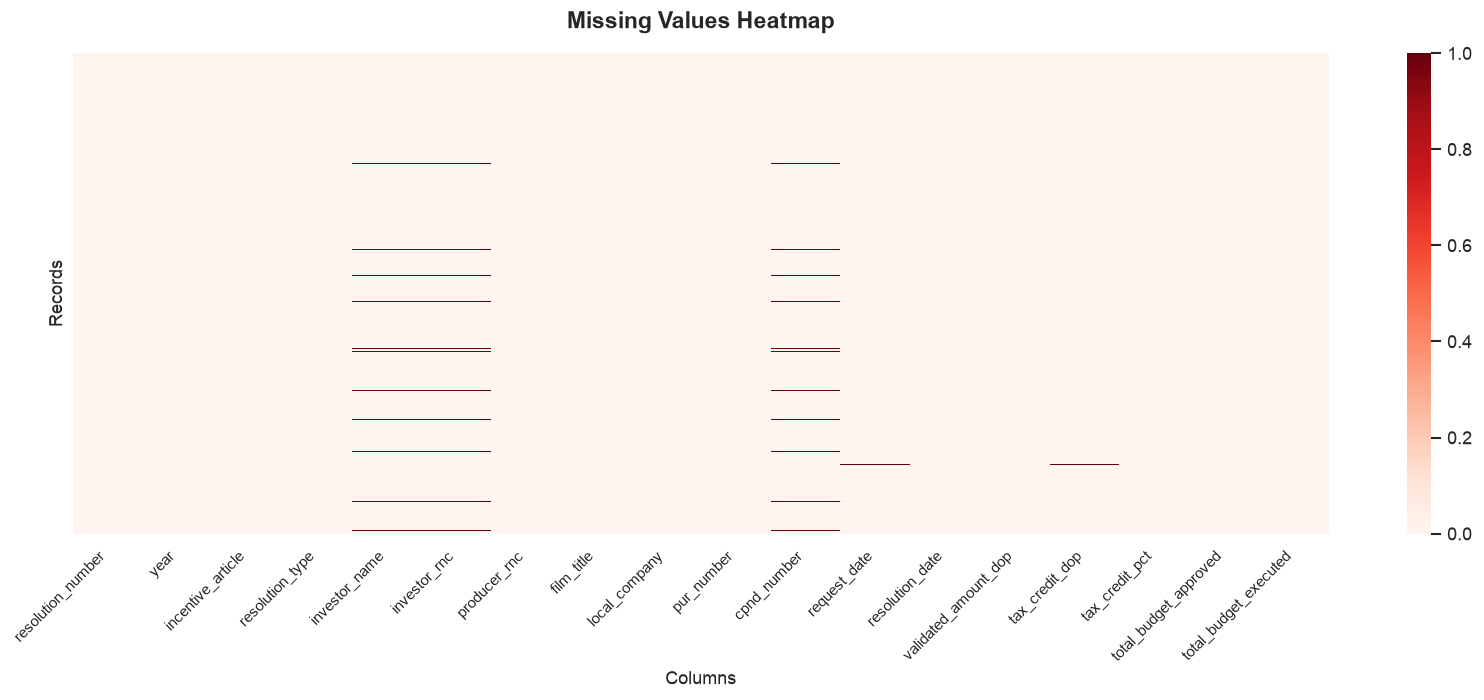

In [7]:
# Heatmap of missing values
fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    df.isnull(),
    cbar=True,
    cmap='Reds',
    yticklabels=False,
    ax=ax
)

ax.set_title('Missing Values Heatmap', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Columns', fontsize=11)
ax.set_ylabel('Records', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

### 3b. Resolution Gaps (404)

CIPAC resolutions are official public documents that should be sequentially numbered and publicly available on the DGCINE website. A manual review identified **229 resolution numbers** that returned a 404 error at the time of data collection. The reasons for their absence are unknown and may represent a transparency concern.

In [8]:
# Resolution gaps (404) by year
missing_res = pd.read_csv('../data/02_missing_resolutions.csv', sep=';', encoding='utf-8-sig')
missing_404 = missing_res[missing_res['status'] == 'Not found (404)']
gaps_by_year = missing_404.groupby('year').size().reset_index(name='count')

fig = px.bar(
    gaps_by_year,
    x='year',
    y='count',
    title='Missing Resolutions (404) by Year',
    labels={'year': 'Year', 'count': 'Number of Missing Resolutions'},
    color='count',
    color_continuous_scale='Reds'
)
fig.update_layout(
    coloraxis_showscale=False,
    yaxis=dict(tickformat=',.0f')
)
fig.show()

# Summary table
gaps_table = gaps_by_year.copy()
gaps_table.columns = ['Year', 'Missing Resolutions (404)']
gaps_table = gaps_table.set_index('Year')
gaps_table

,Missing Resolutions (404)
Year,
2013,3
2015,1
2017,2
2018,7
2020,4
2022,22
2023,14
2024,155
2025,12


### 3c. Duplicate Analysis

In [9]:
# Duplicate Analysis
# Note: CIPAC-2024-301 was found with two different resolutions sharing the same number
# (DGCINE numbering error). These were manually corrected to CIPAC-2024-301-A and CIPAC-2024-301-B.

dup_numbers = df[df.duplicated(subset=['resolution_number'], keep=False)]

print(f"Total records: {len(df)}")
print(f"Exact duplicate resolution numbers: {df['resolution_number'].duplicated().sum()}")
print(f"Records involved: {len(dup_numbers)}")

dup_groups = df.groupby('resolution_number').filter(lambda x: len(x) > 1)

if len(dup_groups) > 0:
    print(f"\nResolution numbers shared by multiple records: {dup_groups['resolution_number'].nunique()}")
    print(dup_groups[['resolution_number', 'year', 'investor_name', 'film_title']].to_string())
else:
    print("\nNo shared resolution numbers found.")

Total records: 2543
Exact duplicate resolution numbers: 0
Records involved: 0

No shared resolution numbers found.


## 4. Outlier Analysis

Identifying extreme values in the key numerical variables that may affect the analysis.

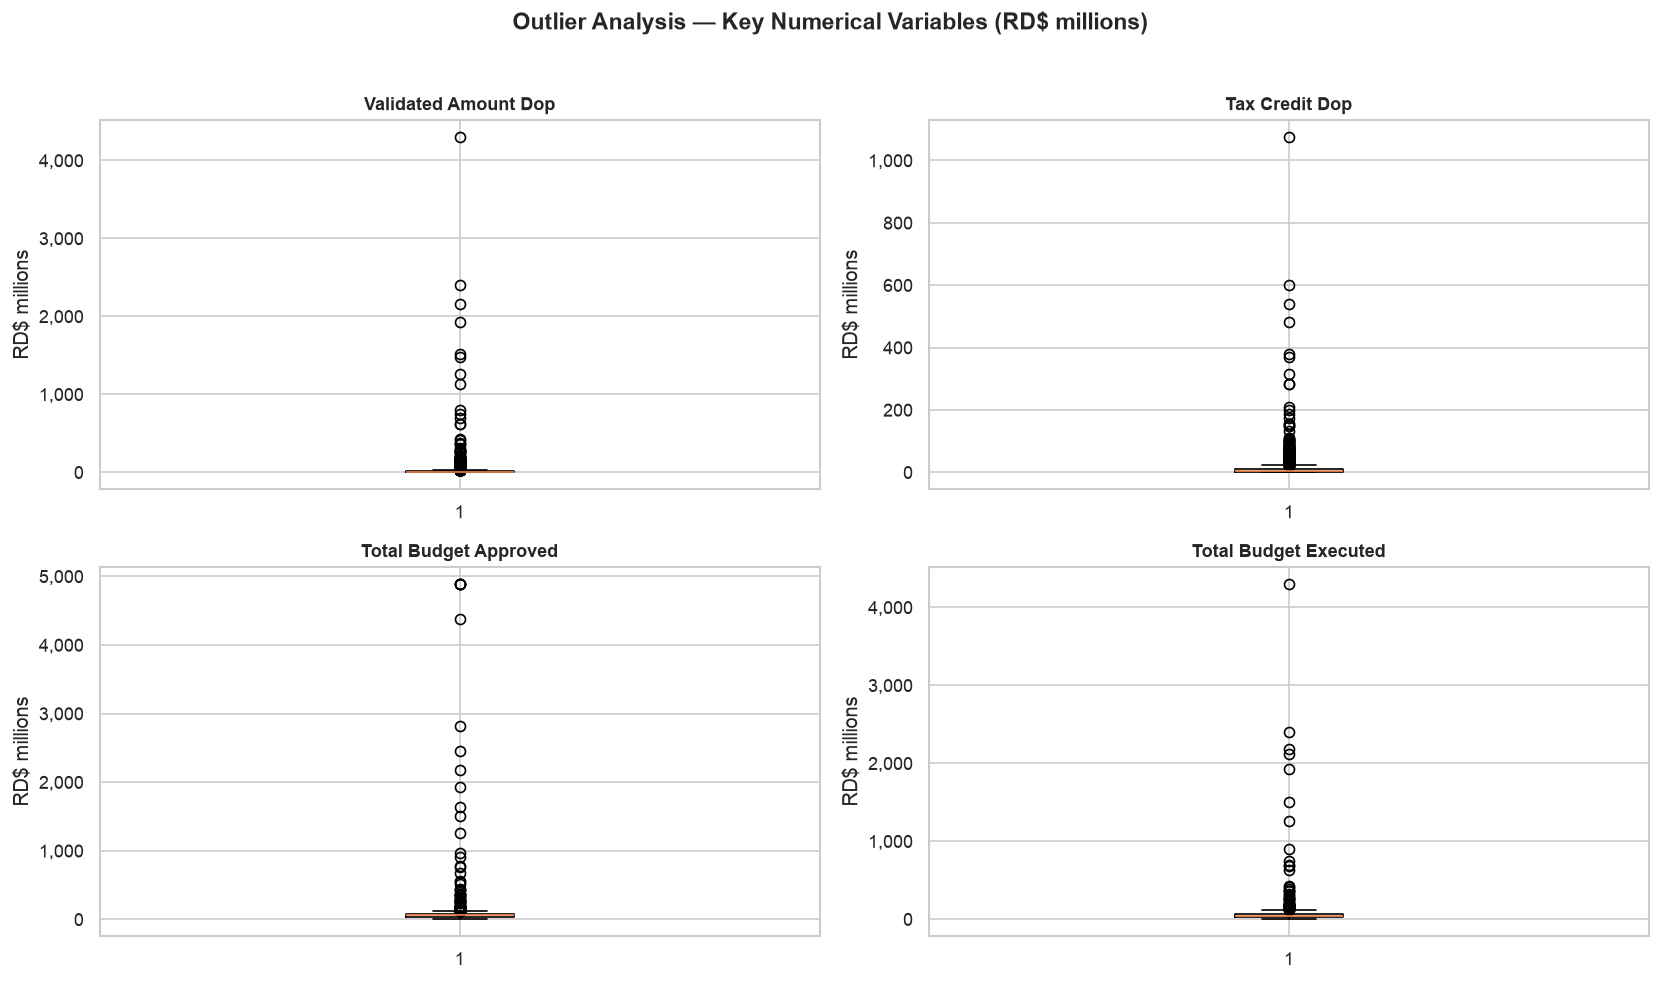

In [10]:
# Outlier Analysis — Boxplots
df_approved_temp = df[df['resolution_type'] == 'approved']

numeric_cols = ['validated_amount_dop', 'tax_credit_dop', 
                'total_budget_approved', 'total_budget_executed']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = df_approved_temp[col].dropna() / 1_000_000
    axes[i].boxplot(data, orientation='vertical')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_ylabel('RD$ millions')
    axes[i].yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
    )

plt.suptitle('Outlier Analysis — Key Numerical Variables (RD$ millions)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Outlier summary using IQR method
summary = []
for col in numeric_cols:
    data = df_approved_temp[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
    summary.append([col, len(outliers), f"{len(outliers)/len(data)*100:.1f}%",
                    f"{data.min()/1e6:,.1f}", f"{data.max()/1e6:,.1f}"])

pd.DataFrame(summary, columns=['Variable', 'Outliers', '%', 'Min (M)', 'Max (M)'])

,Variable,Outliers,%,Min (M),Max (M)
0,validated_amount_dop,294,11.6%,0.0,"4,302.2"
1,tax_credit_dop,269,10.6%,0.0,"1,075.6"
2,total_budget_approved,105,4.1%,3.2,"4,891.2"
3,total_budget_executed,60,2.4%,0.1,"4,302.2"


## 5. Resolutions by Year

Analyzing how CIPAC resolution volume has evolved year over year from 2012 to 2026.

In [12]:
# Resolutions per year
res_per_year = df['year'].value_counts().sort_index().reset_index()
res_per_year.columns = ['year', 'count']

fig = px.scatter(
    res_per_year,
    x='year',
    y='count',
    title='CIPAC Resolutions by Year (2012–2026)',
    labels={'year': 'Year', 'count': 'Number of Resolutions'},
    trendline='ols',
    trendline_color_override='red'
)
fig.update_traces(marker_color='#1f77b4', selector=dict(mode='markers'))
fig.add_scatter(
    x=res_per_year['year'],
    y=res_per_year['count'],
    mode='lines+markers',
    line_color='#1f77b4',
    marker_color='#1f77b4',
    showlegend=False
)
fig.update_layout(showlegend=True)
fig.show()

print(f"\nPeak year:   {res_per_year.loc[res_per_year['count'].idxmax(), 'year']} ({res_per_year['count'].max()} resolutions)")
print(f"Lowest year: {res_per_year.loc[res_per_year['count'].idxmin(), 'year']} ({res_per_year['count'].min()} resolutions)")
print(f"Average:     {res_per_year['count'].mean():.0f} resolutions/year")

print(f"\nTotal approved:  {len(df[df['resolution_type'] == 'approved'])}")
print(f"Total rejected:  {len(df[df['resolution_type'] == 'rejected'])}")


Peak year:   2023 (330 resolutions)
Lowest year: 2012 (14 resolutions)
Average:     170 resolutions/year

Total approved:  2539
Total rejected:  4


In [13]:
# ── Filter approved resolutions for financial analysis ──
df_approved = df[df['resolution_type'] == 'approved']
df_34 = df_approved[df_approved['incentive_article'] == 'art_34']
df_39 = df_approved[df_approved['incentive_article'] == 'art_39']

print(f"Approved resolutions: {len(df_approved)}")
print(f"  Art. 34: {len(df_34)}")
print(f"  Art. 39: {len(df_39)}")

Approved resolutions: 2539
  Art. 34: 2455
  Art. 39: 84


## 6. Time Series Analysis

Analyzing temporal patterns in CIPAC resolution activity, including processing times, monthly distribution, and quarterly trends.

In [14]:
# Convert date columns if not already done
df['request_date'] = pd.to_datetime(df['request_date'])
df['resolution_date'] = pd.to_datetime(df['resolution_date'])

### 6a. Processing Time (request_date → resolution_date)

In [15]:
# Processing time in days
df_time = df_approved[df_approved['request_date'].notna() & df_approved['resolution_date'].notna()].copy()
df_time['processing_days'] = (df_time['resolution_date'] - df_time['request_date']).dt.days
df_time = df_time[df_time['processing_days'] >= 0]

print(f"Records with both dates: {len(df_time)}")
print(f"\nAverage processing time: {df_time['processing_days'].mean():.0f} days")
print(f"Median processing time:  {df_time['processing_days'].median():.0f} days")
print(f"Min processing time:     {df_time['processing_days'].min():.0f} days")
print(f"Max processing time:     {df_time['processing_days'].max():.0f} days")

Records with both dates: 2536

Average processing time: 32 days
Median processing time:  29 days
Min processing time:     0 days
Max processing time:     218 days


In [16]:
# Processing time by year
proc_by_year = df_time.groupby('year')['processing_days'].mean().reset_index()
proc_by_year.columns = ['year', 'avg_days']

fig = px.scatter(
    proc_by_year,
    x='year',
    y='avg_days',
    title='Average Processing Time by Year (days)',
    labels={'year': 'Year', 'avg_days': 'Average Days'},
    trendline='lowess',
    trendline_color_override='red'
)
fig.update_traces(marker_color='#1f77b4', selector=dict(mode='markers'))
fig.add_scatter(
    x=proc_by_year['year'],
    y=proc_by_year['avg_days'],
    mode='lines+markers',
    line_color='#1f77b4',
    marker_color='#1f77b4',
    showlegend=False
)
fig.show()

In [17]:
# Top 15 projects with longest processing time
top15_time = (
    df_time
    .sort_values('processing_days', ascending=False)
    .drop_duplicates(subset='film_title', keep='first')
    .head(15)
    .copy()
)

top15_time['request_date_str'] = top15_time['request_date'].dt.strftime('%Y-%m-%d')
top15_time['resolution_date_str'] = top15_time['resolution_date'].dt.strftime('%Y-%m-%d')
top15_time['article_label'] = top15_time['incentive_article'].map({
    'art_34': 'Art. 34',
    'art_39': 'Art. 39'
})

cols_display = [
    'resolution_number', 'film_title', 'local_company',
    'article_label', 'year', 'request_date_str',
    'resolution_date_str', 'processing_days'
]

top15_display = top15_time[cols_display].reset_index(drop=True)
top15_display.index += 1

top15_display.columns = [
    'Resolution #', 'Film Title', 'Production Company',
    'Article', 'Year', 'Request Date',
    'Resolution Date', 'Processing Days'
]

top15_display.style \
    .background_gradient(subset=['Processing Days'], cmap='Reds') \
    .set_caption('Top 15 Projects by Longest Processing Time') \
    .format({'Processing Days': '{:,}'}) \
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('font-size', '14px'),
            ('font-weight', 'bold')
        ]},
        {'selector': 'th', 'props': [
            ('background-color', '#d62728'),
            ('color', 'white')
        ]},
    ])

,Resolution #,Film Title,Production Company,Article,Year,Request Date,Resolution Date,Processing Days
1,CIPAC-2017-105,THE TRUE MEMOIRS OF AN INTERNATIONAL ASSASSIN,"INVERSIONES BASKIRIA, S.R.L.",Art. 39,2017,2016-10-05,2017-05-11,218
2,CIPAC-2015-081,SURVIVOR,"ÚNICO FILMS, S.R.L.",Art. 39,2015,2014-10-30,2015-04-30,182
3,CIPAC-2018-171,ESPAÑOLES POR EL CARIBE,"HELIX, S.R.L.",Art. 34,2018,2018-01-02,2018-06-07,156
4,CIPAC-2018-167,CAUGHT,"FILM 003, INC",Art. 39,2018,2018-01-03,2018-06-07,155
5,CIPAC-2018-168,SURVIVOR TURQUÍA-GRECIA 2017,"SOUTH WEST PRODUCTIONS, S.R.L.",Art. 39,2018,2018-01-04,2018-06-07,154
6,CIPAC-2017-110,SURVIVOR TURKEY 2016,"DENZET INTERNATIONAL, S.R.L.",Art. 39,2017,2017-01-02,2017-06-01,150
7,CIPAC-2017-108,XXX3: THE RETURN OF XANDER CAGE,"FILM006, INC",Art. 39,2017,2017-01-06,2017-06-01,146
8,CIPAC-2017-134,ARE YOU THE ONE? SEASON 5,"CARIBEMOTION RD, S.R.L.",Art. 39,2017,2017-06-13,2017-10-26,135
9,CIPAC-2018-169,CHRIS MORRIS PROJECT,"FILM 007, INC",Art. 39,2018,2018-01-23,2018-06-07,135
10,CIPAC-2013-035,A RITMO DE FE,"PRODUCCIONES CIRCUS LIVE, E.I.R.L.",Art. 34,2013,2013-02-11,2013-06-17,126


### 6b. Monthly Distribution

In [18]:
# Resolutions by month
df['month'] = df['resolution_date'].dt.month
monthly = df.groupby('month').size().reset_index(name='count')
monthly['month_name'] = pd.to_datetime(monthly['month'], format='%m').dt.strftime('%B')

fig = px.line(
    monthly,
    x='month_name',
    y='count',
    title='Resolutions by Month (all years combined)',
    labels={'month_name': 'Month', 'count': 'Number of Resolutions'},
    markers=True
)
fig.update_traces(line_color='#1f77b4', marker_color='#1f77b4')
fig.update_layout(
    xaxis={'categoryorder': 'array', 'categoryarray': list(pd.date_range('2020-01', periods=12, freq='MS').strftime('%B'))}
)
fig.show()

In [19]:
# Resolutions by month and year
df['month'] = df['resolution_date'].dt.month
df['month_name'] = pd.to_datetime(df['month'], format='%m').dt.strftime('%B')

monthly_year = df.groupby(['year', 'month', 'month_name']).size().reset_index(name='count').sort_values(['year', 'month'])

fig = px.line(
    monthly_year,
    x='month_name',
    y='count',
    color='year',
    title='Resolutions by Month and Year',
    labels={'month_name': 'Month', 'count': 'Number of Resolutions', 'year': 'Year'},
    markers=True
)
fig.update_layout(
    xaxis={'categoryorder': 'array', 'categoryarray': list(pd.date_range('2020-01', periods=12, freq='MS').strftime('%B'))}
)
fig.show()

### 6c. Quarterly Trends

In [20]:
# Validated amount by quarter
import plotly.graph_objects as go

df_approved['quarter'] = df_approved['resolution_date'].dt.to_period('Q').astype(str)

q = (
    df_approved.groupby(['quarter', 'incentive_article'])['validated_amount_dop']
    .sum().div(1e6).unstack(fill_value=0).reset_index()
)

for col in ['art_34', 'art_39']:
    if col not in q:
        q[col] = 0

q['total'] = q['art_34'] + q['art_39']

fig = go.Figure([
    go.Scatter(
        x=q['quarter'], y=q['total'],
        name='Total', mode='lines',
        fill='tozeroy', opacity=.25,
        line=dict(width=1.5),
        hovertemplate='Total: RD$ %{y:,.1f} M<extra></extra>'
    ),
    go.Scatter(
        x=q['quarter'], y=q['art_34'],
        name='Art. 34', mode='lines+markers',
        line=dict(width=2), marker=dict(size=5),
        hovertemplate='Art. 34: RD$ %{y:,.1f} M<extra></extra>'
    ),
    go.Scatter(
        x=q['quarter'], y=q['art_39'],
        name='Art. 39', mode='lines+markers',
        line=dict(width=2), marker=dict(size=5),
        hovertemplate='Art. 39: RD$ %{y:,.1f} M<extra></extra>'
    )
])

fig.update_layout(
    title='Validated Amount by Quarter',
    xaxis_title='Quarter',
    yaxis_title='Validated Amount (RD$ M)',
    xaxis=dict(type='category'),
    yaxis=dict(tickformat=',.0f'),
    hovermode='x unified',
    legend_title='Incentive Article'
)

fig.show()

## 6. Art. 34 vs Art. 39

Analyzing the distribution between Dominican productions (Art. 34) and foreign productions (Art. 39) under Law 108-10.

In [21]:
# Distribution by incentive article
article_counts = df['incentive_article'].value_counts()
article_labels = {'art_34': 'Art. 34 (Dominican)', 'art_39': 'Art. 39 (Foreign)'}
article_counts.index = article_counts.index.map(article_labels)

fig = px.pie(
    values=article_counts.values,
    names=article_counts.index,
    title='Resolutions by Incentive Article',
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.show()

In [22]:
# Resolutions by year and incentive article
df['article_label'] = df['incentive_article'].map(article_labels)

res_by_year_article = df.groupby(['year', 'article_label']).size().reset_index(name='count')

fig = px.bar(
    res_by_year_article,
    x='year',
    y='count',
    color='article_label',
    title='Resolutions by Year and Incentive Article',
    labels={'year': 'Year', 'count': 'Number of Resolutions', 'article_label': 'Article'},
    barmode='stack'
)
fig.show()

In [23]:
# Distribution by incentive article and resolution type
art_type = df.groupby(['incentive_article', 'resolution_type']).size().reset_index(name='count')
art_type['article_label'] = art_type['incentive_article'].map({
    'art_34': 'Art. 34 (Dominican)',
    'art_39': 'Art. 39 (Foreign)'
})

fig = px.bar(
    art_type,
    x='article_label',
    y='count',
    color='resolution_type',
    title='Resolutions by Incentive Article and Resolution Type',
    labels={'article_label': 'Incentive Article', 'count': 'Number of Resolutions', 'resolution_type': 'Resolution Type'},
    barmode='group',
    color_discrete_map={'approved': '#1f77b4', 'rejected': '#d62728'}
)
fig.show()

print(f"\nArt. 34 — Approved: {len(df[(df['incentive_article'] == 'art_34') & (df['resolution_type'] == 'approved')])} | Rejected: {len(df[(df['incentive_article'] == 'art_34') & (df['resolution_type'] == 'rejected')])}")
print(f"Art. 39 — Approved: {len(df[(df['incentive_article'] == 'art_39') & (df['resolution_type'] == 'approved')])} | Rejected: {len(df[(df['incentive_article'] == 'art_39') & (df['resolution_type'] == 'rejected')])}")
print(f"\nTotal  — Approved: {len(df[df['resolution_type'] == 'approved'])} | Rejected: {len(df[df['resolution_type'] == 'rejected'])}")


Art. 34 — Approved: 2455 | Rejected: 4
Art. 39 — Approved: 84 | Rejected: 0

Total  — Approved: 2539 | Rejected: 4


### For the following sections, only **approved** resolutions are included since rejected resolutions do not have validated amounts or tax credits.

## 7. Top Art. 34 Investors

Identifying the most active local investors in Dominican film productions under Art. 34 of Law 108-10. Only Art. 34 resolutions are included, as Art. 39 applies to foreign productions where the applicant is the **foreign producer, not a local investor**.

In [24]:
# Top 15 investors by number of resolutions (Art. 34 only)
df_34 = df[df['incentive_article'] == 'art_34']
top_investors = df_34['investor_name'].value_counts().head(15)

fig = px.bar(
    x=top_investors.values,
    y=top_investors.index,
    orientation='h',
    title='Top 15 Art. 34 Investors by Number of Resolutions',
    labels={'x': 'Number of Resolutions', 'y': 'Investor', 'color': 'Number of Resolutions'},
    color=top_investors.values,
    color_continuous_scale='Blues'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=600)
fig.show()

In [25]:
# Top 15 investors by total tax credit (Art. 34 only)
top_investors_credit = (
    df_34.groupby('investor_name')['tax_credit_dop']
    .sum()
    .dropna()
    .sort_values(ascending=False)
    .head(15)
)

values_millions = top_investors_credit.to_numpy(dtype='float64') / 1_000_000

fig = px.bar(
    x=values_millions,
    y=top_investors_credit.index,
    orientation='h',
    title='Top 15 Art. 34 Investors by Total Tax Credit (RD$ millions)',
    labels={'x': 'Total Tax Credit (RD$ millions)', 'y': 'Investor', 'color': 'Total Tax Credit (RD$ millions)'},
    color=values_millions,
    color_continuous_scale='Greens'
)
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    height=600,
    xaxis=dict(tickformat=',.0f'),
    coloraxis_colorbar=dict(tickformat=',.0f', title='RD$ millions')
)
fig.show()

## 8. Top Art. 34 Production Companies

Identifying the most active Dominican production companies and most funded films under Art. 34 of Law 108-10, based on the number of resolutions, total validated investment amounts, and total investment received from local investors.

In [26]:
# Top 15 Art. 34 production companies by number of resolutions
top_companies_34 = df_34['local_company'].value_counts().head(15)

fig = px.bar(
    x=top_companies_34.values,
    y=top_companies_34.index,
    orientation='h',
    title='Top 15 Art. 34 Production Companies by Number of Resolutions',
    labels={'x': 'Number of Resolutions', 'y': 'Production Company', 'color': 'Number of Resolutions'},
    color=top_companies_34.values,
    color_continuous_scale='Blues'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=600)
fig.show()

In [27]:
# Top 15 Art. 34 production companies by total validated amount
top_companies_34_amount = (
    df_34.groupby('local_company')['validated_amount_dop']
    .sum()
    .dropna()
    .sort_values(ascending=False)
    .head(15)
)

values_millions = top_companies_34_amount.to_numpy(dtype='float64') / 1_000_000

fig = px.bar(
    x=values_millions,
    y=top_companies_34_amount.index,
    orientation='h',
    title='Top 15 Art. 34 Production Companies by Total Validated Amount (RD$ millions)',
    labels={'x': 'Total Validated Amount (RD$ millions)', 'y': 'Production Company', 'color': 'Total Validated Amount (RD$ millions)'},
    color=values_millions,
    color_continuous_scale='Purples'
)
fig.update_layout(
    title='Top 15 Art. 34 Production Companies<br>by Total Validated Amount (RD$ millions)',
    yaxis={'categoryorder': 'total ascending'},
    height=600,
    xaxis=dict(tickformat=',.0f'),
    coloraxis_colorbar=dict(tickformat=',.0f', title='RD$ millions')
)
fig.show()

In [28]:
# Top 15 most funded films - Art. 34
top_films_34 = (
    df_34.groupby('film_title')['validated_amount_dop']
    .sum().dropna().sort_values(ascending=False).head(15)
)
values_34 = top_films_34.to_numpy(dtype='float64') / 1e6

fig = px.bar(
    x=values_34, y=top_films_34.index, orientation='h',
    title='Top 15 Most Funded Films by Total Validated Investment<br>(Art. 34 — RD$ millions)',
    labels={'x': 'Total Validated Investment (RD$ M)', 'y': 'Film Title', 'color': 'RD$ millions'},
    color=values_34, color_continuous_scale='Blues'
)
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'}, height=600,
    xaxis=dict(tickformat=',.0f'),
    coloraxis_colorbar=dict(tickformat=',.0f', title='RD$ M')
)
fig.show()

## 9. Top Art. 39 Production Companies

Identifying the most active local production companies representing foreign productions and most funded films under Art. 39 of Law 108-10, based on the number of resolutions and total validated expenses in the Dominican Republic.

In [29]:
# Top 15 foreign productions by number of resolutions (Art. 39 only)
df_39 = df[df['incentive_article'] == 'art_39']
top_foreign = df_39['local_company'].value_counts().head(15)

fig = px.bar(
    x=top_foreign.values,
    y=top_foreign.index,
    orientation='h',
    title='Top 15 Art. 39 Production Companies by Number of Resolutions',
    labels={'x': 'Number of Resolutions', 'y': 'Production Company', 'color': 'Number of Resolutions'},
    color=top_foreign.values,
    color_continuous_scale='Oranges'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=600)
fig.show()

In [30]:
# Top 15 foreign productions by total validated expenses (Art. 39 only)
top_foreign_expenses = (
    df_39.groupby('local_company')['validated_amount_dop']
    .sum()
    .dropna()
    .sort_values(ascending=False)
    .head(15)
)

values_millions = top_foreign_expenses.to_numpy(dtype='float64') / 1_000_000

fig = px.bar(
    x=values_millions,
    y=top_foreign_expenses.index,
    orientation='h',
    title='Top 15 Art. 39 Production Companies<br>by Total Validated Expenses (RD$ millions)',
    labels={'x': 'Total Validated Expenses (RD$ millions)', 'y': 'Production Company', 'color': 'Total Validated Expenses (RD$ millions)'},
    color=values_millions,
    color_continuous_scale='Oranges'
)
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    height=600,
    xaxis=dict(tickformat=',.0f'),
    coloraxis_colorbar=dict(tickformat=',.0f', title='RD$ millions')
)
fig.show()

In [31]:
# Top 15 most funded films - Art. 39
top_films_39 = (
    df_39.groupby('film_title')['validated_amount_dop']
    .sum().dropna().sort_values(ascending=False).head(15)
)
values_39 = top_films_39.to_numpy(dtype='float64') / 1e6

fig = px.bar(
    x=values_39, y=top_films_39.index, orientation='h',
    title='Top 15 Most Funded Films by Total Validated Expenses<br>(Art. 39 — RD$ millions)',
    labels={'x': 'Total Validated Expenses (RD$ M)', 'y': 'Film Title', 'color': 'RD$ millions'},
    color=values_39, color_continuous_scale='Oranges'
)
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'}, height=600,
    xaxis=dict(tickformat=',.0f'),
    coloraxis_colorbar=dict(tickformat=',.0f', title='RD$ M')
)
fig.show()

## 10. Film Analysis

Analyzing the number of resolutions per film title, broken down by incentive article. A film with multiple resolutions indicates multiple investors (Art. 34) or multiple validation requests (Art. 39).

In [32]:
# All films — Resolutions count
films_all = df_approved.groupby(['film_title', 'local_company']).size().reset_index(name='resolutions')
films_all = films_all.sort_values('resolutions', ascending=False).head(15).reset_index(drop=True)
films_all.index += 1
films_all.columns = ['Film Title', 'Production Company', 'Resolutions']

films_all.style \
    .background_gradient(subset=['Resolutions'], cmap='Blues') \
    .set_caption('Top 15 Films by Number of Resolutions') \
    .format({'Resolutions': '{:,}'}) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#1f77b4'), ('color', 'white')]},
    ])

,Film Title,Production Company,Resolutions
1,EL PODER DE LAS TINIEBLAS,"LILO PRODUCTIONS, S.R.L.",28
2,DANNY LA BALA,"LA BALA PRODUCTIONS, S.R.L.",20
3,LUNA NEGRA,"PILÓN PRODUCTIONS, S.R.L.",19
4,LA BRUJA,"FÉNIX LEGENDARIO STUDIOS, S.R.L.",19
5,REINBOU,"CACIQUE FILMS, S.R.L.",18
6,ASALTO EN PROGRESO,"ASALTO EN PROGRESO, S.R.L.",17
7,DOS POLICIAS EN APUROS,"ALDEA FILMS, S.R.L.",15
8,MISIÓN 809,"GRUPO TRUKEMER, S.R.L.",15
9,VENENO,"FRÍO FRÍO PRODUCTORA CINEMATOGRÁFICA, S.R.L.",15
10,VÍCTOR,"BOLECA FILMS, S.R.L.",15


In [33]:
# Art. 34 — Resolutions per film
films_34_count = df_34.groupby(['film_title', 'local_company']).size().reset_index(name='resolutions')
films_34_count = films_34_count.sort_values('resolutions', ascending=False).head(15).reset_index(drop=True)
films_34_count.index += 1
films_34_count.columns = ['Film Title', 'Production Company', 'Resolutions']

print(f"Total unique Art. 34 films: {df_34['film_title'].nunique()}")
print(f"Films with 1 resolution:    {len(df_34.groupby('film_title').filter(lambda x: len(x)==1)['film_title'].unique())}")
print(f"Films with 2+ resolutions:  {len(df_34.groupby('film_title').filter(lambda x: len(x)>1)['film_title'].unique())}")
print(f"Films with 5+ resolutions:  {len(df_34.groupby('film_title').filter(lambda x: len(x)>=5)['film_title'].unique())}")
print()

films_34_count.style \
    .background_gradient(subset=['Resolutions'], cmap='Blues') \
    .set_caption('Top 15 Art. 34 Films by Number of Resolutions') \
    .format({'Resolutions': '{:,}'}) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#1f77b4'), ('color', 'white')]},
    ])

Total unique Art. 34 films: 587
Films with 1 resolution:    158
Films with 2+ resolutions:  429
Films with 5+ resolutions:  211



,Film Title,Production Company,Resolutions
1,EL PODER DE LAS TINIEBLAS,"LILO PRODUCTIONS, S.R.L.",28
2,DANNY LA BALA,"LA BALA PRODUCTIONS, S.R.L.",20
3,LA BRUJA,"FÉNIX LEGENDARIO STUDIOS, S.R.L.",19
4,LUNA NEGRA,"PILÓN PRODUCTIONS, S.R.L.",19
5,REINBOU,"CACIQUE FILMS, S.R.L.",18
6,ASALTO EN PROGRESO,"ASALTO EN PROGRESO, S.R.L.",17
7,VÍCTOR,"BOLECA FILMS, S.R.L.",15
8,DOS POLICIAS EN APUROS,"ALDEA FILMS, S.R.L.",15
9,VENENO,"FRÍO FRÍO PRODUCTORA CINEMATOGRÁFICA, S.R.L.",15
10,MISIÓN 809,"GRUPO TRUKEMER, S.R.L.",15


In [34]:
# Art. 39 — Resolutions per film
films_39_count = df_39.groupby(['film_title', 'local_company']).size().reset_index(name='resolutions')
films_39_count = films_39_count.sort_values('resolutions', ascending=False).head(15).reset_index(drop=True)
films_39_count.index += 1
films_39_count.columns = ['Film Title', 'Production Company', 'Resolutions']

print(f"Total unique Art. 39 films: {df_39['film_title'].nunique()}")
print()

films_39_count.style \
    .background_gradient(subset=['Resolutions'], cmap='Oranges') \
    .set_caption('Top 15 Art. 39 Films by Number of Resolutions') \
    .format({'Resolutions': '{:,}'}) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#ff7f0e'), ('color', 'white')]},
    ])

Total unique Art. 39 films: 78



,Film Title,Production Company,Resolutions
1,47 METERS DOWN: THE NEXT CHAPTER,"FILM 011, S.R.L.",2
2,CHRIS MORRIS PROJECT,"FILM 007, INC",2
3,SURVIVOR PAÍSES NÓRDICOS,"J WITCHES & JONES, S.R.L.",2
4,EXPEDICIÓN SAMANA,"INTERNATIONAL FILMS PRODUCTIONS INFILPROD, S.R.L.",2
5,EL CONQUISTADOR DEL FIN DEL MUNDO TEMPORADA 21,"INTERNATIONAL FILMS PRODUCTIONS INFILPROD, S.R.L.",2
6,EL CONQUISTADOR DEL CARIBE - TEMPORADA 1,"INTERNATIONAL FILMS PRODUCTIONS INFILPROD, S.R.L.",2
7,ARTHUR THE KING,"FILM 023, S.R.L.",1
8,ASUNTOS EXTRANJEROS EN CUBA,"COMPAÑÍA INTERNACIONAL DOMINICANA CID, S.R.L.",1
9,BEAUTIFUL WEDDING,"FILM 044, S.R.L.",1
10,ATTACKED,"FILM 013, S.R.L.",1


## 11. Validated Amounts & Tax Credits

Analyzing the relationship between resolution volume and total validated investment amounts and tax credits issued under Law 108-10, broken down by incentive article (Art. 34 and Art. 39).

In [35]:
# Volume vs Validated Amount by year
yearly_volume = (df_approved.groupby(['year', 'incentive_article'])
                 .agg(total_validated_m=('validated_amount_dop', lambda x: x.sum() / 1e6))
                 .reset_index()
                 .sort_values('year'))
yearly_volume['article_label'] = yearly_volume['incentive_article'].map({'art_34': 'Art. 34', 'art_39': 'Art. 39'})

yearly_count = df_approved.groupby('year')['resolution_number'].count().reset_index(name='count').sort_values('year')

fig = px.area(yearly_volume, x='year', y='total_validated_m', color='article_label',
              title='Annual Resolutions Count vs Total Validated Amount',
              labels={'total_validated_m': 'Total Validated (RD$ M)', 'article_label': 'Article'},
              color_discrete_map={'Art. 34': '#1f77b4', 'Art. 39': '#ff7f0e'})
fig.add_scatter(x=yearly_count['year'], y=yearly_count['count'],
                mode='lines+markers', name='Resolutions', yaxis='y2', line=dict(color='green'))
fig.update_layout(xaxis=dict(categoryorder='array', categoryarray=sorted(yearly_volume['year'].unique())),
                  yaxis=dict(tickformat=',.0f'),
                  yaxis2=dict(overlaying='y', side='right', title='Resolutions', color='green'),
                  legend=dict(orientation='h', y=-0.2, x=0.5, xanchor='center'))
fig.show()

In [36]:
# Total validated amount and tax credit by year (all articles combined)
yearly_total = df_approved.groupby('year').agg(
    total_validated=('validated_amount_dop', 'sum'),
    total_credit=('tax_credit_dop', 'sum')
).reset_index()

yearly_total['total_validated_m'] = yearly_total['total_validated'] / 1_000_000
yearly_total['total_credit_m'] = yearly_total['total_credit'] / 1_000_000

fig = go.Figure()

fig.add_trace(go.Bar(
    x=yearly_total['year'],
    y=yearly_total['total_validated_m'],
    name='Validated Amount',
    marker_color='#1f77b4'
))

fig.add_trace(go.Bar(
    x=yearly_total['year'],
    y=yearly_total['total_credit_m'],
    name='Tax Credit',
    marker_color='#2ca02c'
))

fig.update_layout(
    title='Total Validated Amount vs Tax Credit by Year (RD$ millions)',
    xaxis_title='Year',
    yaxis_title='RD$ millions',
    barmode='group',
    yaxis=dict(tickformat=',.0f')
)
fig.show()

In [37]:
# By incentive article
yearly = df_approved.groupby(['year', 'incentive_article']).agg(
    total_validated=('validated_amount_dop', 'sum'),
    total_credit=('tax_credit_dop', 'sum')
).reset_index()

yearly['total_validated_m'] = yearly['total_validated'] / 1_000_000
yearly['total_credit_m'] = yearly['total_credit'] / 1_000_000
yearly['article_label'] = yearly['incentive_article'].map({
    'art_34': 'Art. 34',
    'art_39': 'Art. 39'
})

fig = px.bar(
    yearly,
    x='year',
    y='total_validated_m',
    color='article_label',
    title='Total Validated Amount by Year and Incentive Article (RD$ millions)',
    labels={'year': 'Year', 'total_validated_m': 'Total Validated Amount (RD$ millions)', 'article_label': 'Article'},
    barmode='group',
    color_discrete_map={'Art. 34': '#1f77b4', 'Art. 39': '#ff7f0e'}
)
fig.update_layout(yaxis=dict(tickformat=',.0f'))
fig.show()

fig = px.bar(
    yearly,
    x='year',
    y='total_credit_m',
    color='article_label',
    title='Total Tax Credit by Year and Incentive Article (RD$ millions)',
    labels={'year': 'Year', 'total_credit_m': 'Total Tax Credit (RD$ millions)', 'article_label': 'Article'},
    barmode='group',
    color_discrete_map={'Art. 34': '#1f77b4', 'Art. 39': '#ff7f0e'}
)
fig.update_layout(yaxis=dict(tickformat=',.0f'))
fig.show()

In [38]:
# Average tax credit per resolution by year and incentive article
avg_credit = df_approved.groupby(['year', 'incentive_article'])['tax_credit_dop'].mean().reset_index()
avg_credit['tax_credit_m'] = avg_credit['tax_credit_dop'] / 1_000_000
avg_credit['article_label'] = avg_credit['incentive_article'].map({
    'art_34': 'Art. 34',
    'art_39': 'Art. 39'
})

fig = px.line(
    avg_credit,
    x='year',
    y='tax_credit_m',
    color='article_label',
    title='Average Tax Credit per Resolution by Year (RD$ millions)',
    labels={'year': 'Year', 'tax_credit_m': 'Average Tax Credit (RD$ millions)', 'article_label': 'Article'},
    markers=True,
    color_discrete_map={'Art. 34': '#1f77b4', 'Art. 39': '#ff7f0e'}
)
fig.update_layout(yaxis=dict(tickformat=',.0f'))
fig.show()

## 12. Correlation Analysis

Exploring relationships between the key numerical variables in the dataset.

In [39]:
# Correlation matrix
numeric_cols = ['validated_amount_dop', 'tax_credit_dop', 'tax_credit_pct', 
                'total_budget_approved', 'total_budget_executed']

corr = df_approved[numeric_cols].corr()

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    zmin=-1,
    zmax=1,
    title='Correlation Matrix — Numerical Variables'
)
fig.update_layout(
    width=600,
    height=500,
    coloraxis_colorbar=dict(title='Correlation')
)
fig.show()

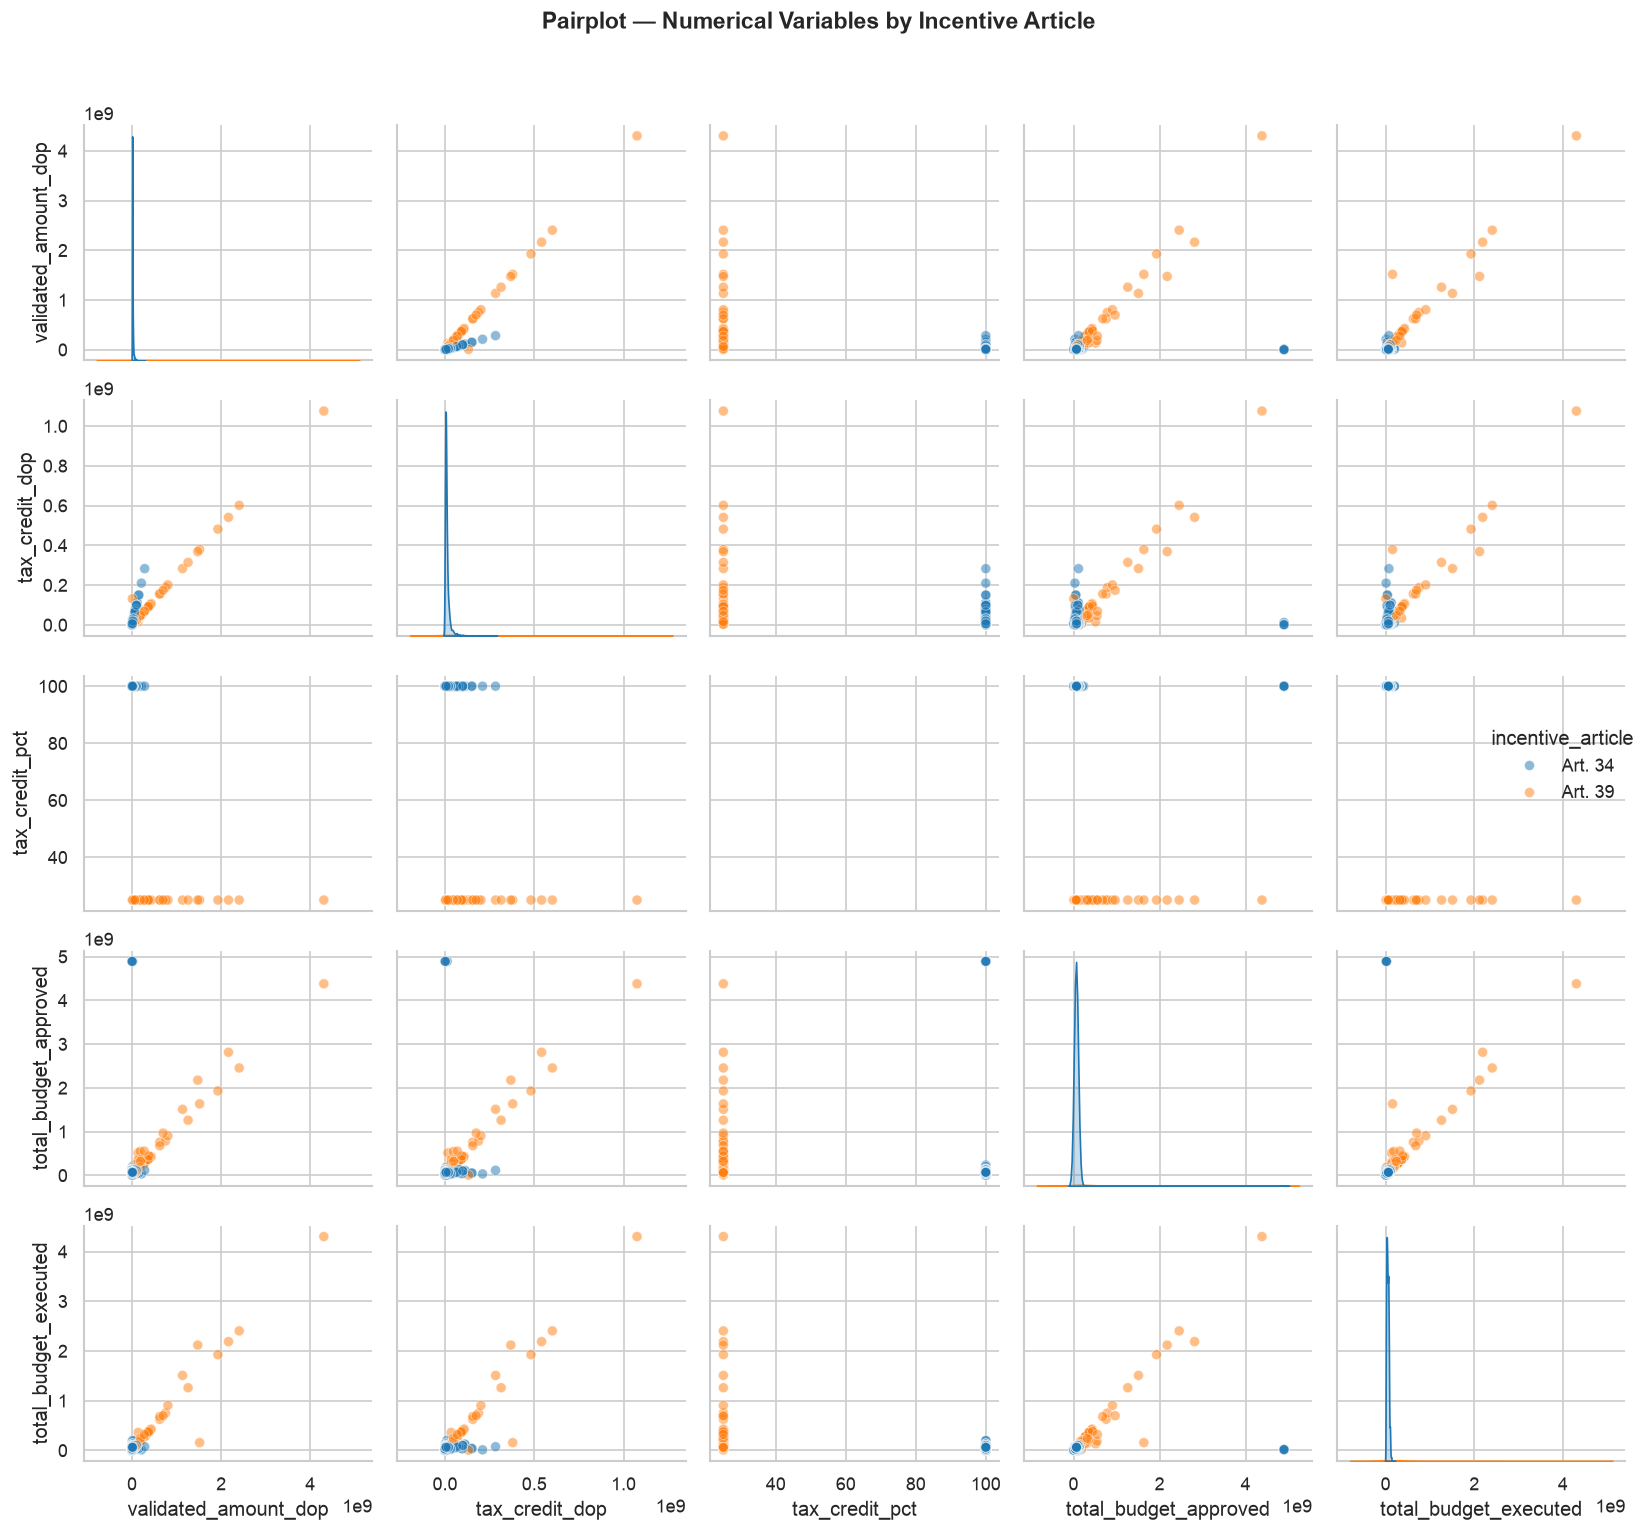

In [40]:
# Pairplot
pairplot_df = df_approved[numeric_cols + ['incentive_article']].dropna()
pairplot_df['incentive_article'] = pairplot_df['incentive_article'].map({
    'art_34': 'Art. 34',
    'art_39': 'Art. 39'
})

g = sns.pairplot(
    pairplot_df,
    hue='incentive_article',
    hue_order=['Art. 34', 'Art. 39'],
    palette={'Art. 34': '#1f77b4', 'Art. 39': '#ff7f0e'},
    plot_kws={'alpha': 0.5},
    diag_kind='kde'
)

g.figure.suptitle('Pairplot — Numerical Variables by Incentive Article',
                   fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 13. Budget Analysis (Approved vs Executed)

Comparing the approved production budgets against the actual executed budgets across years.

In [41]:
# Average approved vs executed budget by year
budget_year = df_approved.groupby('year').agg(
    avg_approved=('total_budget_approved', 'mean'),
    avg_executed=('total_budget_executed', 'mean')
).reset_index()

budget_year['avg_approved_m'] = budget_year['avg_approved'] / 1_000_000
budget_year['avg_executed_m'] = budget_year['avg_executed'] / 1_000_000

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=budget_year['year'],
    y=budget_year['avg_approved_m'],
    mode='lines+markers',
    name='Avg Approved Budget',
    line=dict(color='#1f77b4')
))

fig.add_trace(go.Scatter(
    x=budget_year['year'],
    y=budget_year['avg_executed_m'],
    mode='lines+markers',
    name='Avg Executed Budget',
    line=dict(color='#ff7f0e')
))

fig.update_layout(
    title='Average Approved vs Executed Budget by Year (RD$ millions)',
    xaxis_title='Year',
    yaxis_title='RD$ millions',
    yaxis=dict(tickformat=',.0f')
)
fig.show()

In [42]:
# Budget execution rate by year (executed / approved)
budget_year['execution_rate'] = (
    budget_year['avg_executed'] / budget_year['avg_approved'] * 100
).round(1)

fig = px.bar(
    budget_year,
    x='year',
    y='execution_rate',
    title='Average Budget Execution Rate by Year (%)',
    labels={'year': 'Year', 'execution_rate': 'Execution Rate (%)'},
    color='execution_rate',
    color_continuous_scale='RdYlGn'
)
fig.update_layout(
    yaxis=dict(tickformat=',.0f'),
    coloraxis_colorbar=dict(title='%')
)
fig.add_hline(y=100, line_dash='dash', line_color='gray', annotation_text='100%')
fig.show()

In [43]:
# Resolutions where execution rate > 100%
exec_rate_df = df_approved[df_approved['total_budget_approved'].notna() & 
                            df_approved['total_budget_executed'].notna()].copy()
exec_rate_df['execution_rate'] = (exec_rate_df['total_budget_executed'] / 
                                   exec_rate_df['total_budget_approved'] * 100).round(1)

over_100 = exec_rate_df[exec_rate_df['execution_rate'] > 100].copy()

print(f"Resolutions exceeding approved budget: {len(over_100)} ({len(over_100)/len(exec_rate_df)*100:.1f}%)\n")

over_100_grouped = over_100.groupby(['film_title', 'local_company']).agg(
    Resolutions=('resolution_number', 'count'),
    Approved=('total_budget_approved', 'first'),
    Executed=('total_budget_executed', 'first'),
    Avg_Execution_Rate=('execution_rate', 'mean')
).reset_index().sort_values('Avg_Execution_Rate', ascending=False).reset_index(drop=True)
over_100_grouped.index += 1
over_100_grouped.columns = ['Film Title', 'Production Company', 'Resolutions', 'Approved (RD$)', 'Executed (RD$)', 'Avg Execution Rate (%)']
over_100_grouped['Avg Execution Rate (%)'] = over_100_grouped['Avg Execution Rate (%)'].round(1)

over_100_grouped.style \
    .background_gradient(subset=['Avg Execution Rate (%)'], cmap='Oranges') \
    .set_caption('Films where Budget Execution Rate > 100%') \
    .format({'Approved (RD$)': '{:,.0f}', 'Executed (RD$)': '{:,.0f}', 'Avg Execution Rate (%)': '{:.1f}%'}) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#ff7f0e'), ('color', 'white')]},
    ])

Resolutions exceeding approved budget: 77 (3.0%)



,Film Title,Production Company,Resolutions,Approved (RD$),Executed (RD$),Avg Execution Rate (%)
1,AZUL MAGIA,"ALDEA FILMS, S.R.L.",1,"5,289,800","19,763,718",373.6%
2,EL PROYECCIONISTA,"GRUPO TRUKEMER, S.R.L.",1,"26,408,648","68,525,264",259.5%
3,SURVIVOR TURKEY 2016,"DENZET INTERNATIONAL, S.R.L.",1,"134,600,398","168,538,679",125.2%
4,THE TRUTH,"FILM001, INC",1,"38,432,098","46,168,272",120.1%
5,EL TÍGUERE: PORFIRIO RUBIROSA II,"LOKAL PRODUCTIONS, S.R.L.",2,"102,723,390","114,750,950",112.4%
6,LOTOMAN 2.0,"DRAGON FILMS, S.R.L.",2,"46,885,882","51,392,493",109.6%
7,LOTOMAN 3,"LOTOMAN 3, S.R.L.",5,"62,588,479","68,498,496",109.4%
8,DOMINICANA'S GOTTALENT - SEGUNDA TEMPORADA,"EAST COAST PRODUCTION, S.R.L.",1,"112,469,216","120,238,672",106.9%
9,PONCHA'O,"ENTREPRENEUR FILMS, S.R.L.",4,"25,000,000","26,279,234",105.1%
10,EL AMOR CAMBIA DE LUGAR,"COLIBRÍ FILMS, S.R.L.",4,"29,158,642","30,360,571",104.1%


## 14. Key Findings & Conclusions

### Dataset Overview
- The dataset contains **2,543 CIPAC resolutions** issued between 2012 and 2026 under Law 108-10, of which **2,539 (99.8%) were approved** and only **4 (0.2%) were rejected**, reflecting CIPAC's very high approval rate.
- **Art. 34** accounts for **2,459 resolutions (96.7%)**, while **Art. 39** accounts for **84 (3.3%)**. Among approved resolutions, Art. 34 represents 2,455 cases and Art. 39 represents 84, while all 4 rejected resolutions belong to Art. 34.
- One DGCINE numbering error was identified and corrected (CIPAC-2024-301 split into -A and -B), and 13 resolutions in 2018 were found to have incorrect year numbering (CIPAC-2017-XXX) which were corrected to CIPAC-2018-XXX.

### Data Quality & Transparency
- The most affected fields are `investor_name`, `investor_rnc`, and `cpnd_number`, with approximately **3.3% missing values**. The 84 missing investor records correspond to Art. 39 resolutions, which by their nature do not involve local investors. The missing CPND values are similarly concentrated in Art. 39 records and therefore should not automatically be interpreted as data-quality errors.
- Only **4 request dates (0.2%)** and **4 tax credit values (0.2%)** are missing, while missing values in budget fields are negligible (`total_budget_approved`: 1; `total_budget_executed`: 2).
- **229 resolution numbers** returned a 404 error on the DGCINE website at the time of data collection. Notably, **2024 accounts for 155 of these gaps**, raising questions about the completeness of publicly available data for that year. Consequently, year-over-year comparisons should be interpreted with caution, particularly for 2024.
- **11.6% of validated amounts** and **10.6% of tax credits** are statistical outliers under the IQR method. The concentration of large Art. 39 productions contributes substantially to these extreme values.

### Resolution Volume
- Resolution volume has grown substantially from **14 resolutions in 2012** to a peak of **330 in 2023**, with an average of **170 resolutions per year**.
- The long-term distribution indicates a significant expansion in CIPAC activity over the period, although annual volume is not uniform.
- **2023 was the peak year**, with 330 resolutions, while 2012 had the lowest volume with only 14 resolutions.
- Year-over-year comparisons should be interpreted with caution because **229 resolution numbers returned a 404 error** across multiple years, with 2024 being the most affected.

### Processing Time & Time Series
- CIPAC processed requests in an average of **32 days**, with a median of **29 days**, based on **2,536 resolutions with both request and resolution dates available**.
- Processing times vary considerably by year. **2017 was the slowest year**, averaging **45.9 days**, followed by 2013 (38.3 days), 2020 (35.9 days), 2018 (35.8 days), and 2024 (34.6 days).
- The fastest average processing occurred in **2012 (10.6 days)**, although the small number of resolutions in that year makes direct comparison less representative.
- Recent processing times remain relatively stable, averaging **29.5 days in 2025** and **28.7 days in 2026**, indicating that processing has remained around the one-month range in recent years.
- Among the **15 projects with the longest processing times**, *The True Memoirs of an International Assassin* (CIPAC-2017-105, Art. 39) ranks first with **218 days**, followed by *Survivor* (CIPAC-2015-081, Art. 39) with **182 days**, *Españoles por el Caribe* (CIPAC-2018-171, Art. 34) with **156 days**, *Caught* (CIPAC-2018-167, Art. 39) with **155 days**, and *Survivor Turquía-Grecia 2017* (CIPAC-2018-168, Art. 39) with **154 days**.
- The longest processing cases are disproportionately represented by **Art. 39 foreign productions**, particularly among the top 15 longest cases, suggesting that certain foreign productions have historically experienced substantially longer validation cycles.
- **February is the most active month** with 710 resolutions, followed by March (554) and January (381), indicating a strong concentration of CIPAC activity during the first quarter of the year.
- Quarterly validated amounts peaked in **2023 Q3 at RD$9,450.7M**, driven overwhelmingly by Art. 39 activity. The five largest quarters are **2023 Q3, 2022 Q1, 2023 Q1, 2022 Q3, and 2026 Q1**.

### Financial Impact
- Total validated investment and expenses across all years reached **RD$52,662.8 million**, generating approximately **RD$30,853 million in tax credits**.
- The financial composition differs substantially between the two incentive mechanisms: **Art. 34 accounts for RD$23,434.1M (44.5%) of validated amounts**, while **Art. 39 accounts for RD$29,228.7M (55.5%)**.
- **Art. 34 represents 96.7% of resolutions but only 44.5% of validated amounts, while Art. 39 represents 3.3% of resolutions but 55.5% of validated amounts.** This highlights the substantially different financial scale of the two incentive mechanisms.
- **2023 Q3 was the peak quarter overall**, with RD$9,450.7M validated. Of this amount, **RD$9,276.1M came from Art. 39**, while Art. 34 accounted for approximately RD$174.6M.
- The largest Art. 34 quarter was **2023 Q1**, with RD$2,476.3M validated.
- The largest Art. 39 quarter was **2023 Q3**, with RD$9,276.1M validated.
- The average tax credit per Art. 39 resolution (**RD$88.3M**) is approximately **9.3 times higher** than the Art. 34 average (**RD$9.5M**), reflecting the significantly larger scale of foreign productions.

### Top Investors (Art. 34)
- **Cervecería Nacional Dominicana, S.A.** and **Banco Popular Dominicano, S. A. Banco Múltiple** are tied for the highest number of Art. 34 resolutions, with **86 resolutions each**.
- **Banco Múltiple BHD, S.A.** follows with 78 resolutions, while **Corporación Aeroportuaria del Este, S.A.S.** has 66 and **Induveca, S.A.** has 50.
- By total tax credit, **Banco Popular** leads with **RD$2,937.7M**, followed by **Cervecería Nacional Dominicana (RD$2,114.6M)**, **Corporación Aeroportuaria del Este (RD$1,642.8M)**, **Banco Múltiple BHD (RD$1,030.8M)**, and **Compañía Dominicana de Teléfonos (RD$943.6M)**.
- The leading Art. 34 investors are predominantly large financial institutions, telecommunications companies, industrial corporations, and infrastructure operators, illustrating the role of corporate investment in Dominican film production incentives.

### Film Analysis (Art. 34)
- The dataset covers **587 unique Art. 34 films**. Of these, **158 (26.9%) have only 1 resolution**, while **429 (73.1%) have 2 or more resolutions**, reflecting the multi-investor nature of Dominican productions.
- **211 films have 5 or more resolutions**, while **47 films have 10 or more resolutions**.
- **El Poder de las Tinieblas** leads with **29 resolutions**, making it the film with the highest number of Art. 34 investor-backed resolutions in the dataset.
- The most funded Art. 34 films by total validated amount are **Danny La Bala (RD$371.7M)**, **Sola a los 40 (RD$308.3M)**, **El Tíguere: Porfirio Rubirosa II (RD$214.1M)**, **La Soga 3 (RD$213.2M)**, and **Capitán Avispa (RD$187.0M)**.
- **Pilón Productions, S.R.L.** leads production company activity with 59 resolutions, followed by **Grupo Trukemer, S.R.L. (51)**, **Larimar Services, S.R.L. (46)**, **Art3+4 Producciones, S.R.L. (45)**, and **Cacique Films, S.R.L. (37)**.

### Film Analysis (Art. 39)
- The dataset covers **78 unique Art. 39 films**, compared with 587 under Art. 34.
- The maximum number of resolutions for a single Art. 39 film is **2**, recorded for *47 Meters Down: The Next Chapter*, reinforcing the predominantly one-time validation pattern of foreign productions.
- **FILM 034, S.R.L.** leads Art. 39 companies by validated expenses with **RD$4,302.2M**, followed by **Diamond MB Productions, S.R.L. (RD$4,033.5M)** and **FILM 046, S.R.L. (RD$2,404.6M)**.
- The largest Art. 39 productions by validated amount are **Road House (RD$4,302.2M)**, **Saint X - Screenplay (Pilot) (RD$2,404.6M)**, **Shotgun Wedding (RD$2,163.4M)**, **Arthur the King (RD$1,926.1M)**, and **NYAD (RD$1,516.0M)**.
- Although Art. 39 represents only **84 resolutions**, it accounts for **55.5% of all validated amounts**, demonstrating its disproportionate financial impact on the overall incentive system.

### Budget Analysis
- The overall average budget execution rate is **67.0%**, indicating that productions generally execute substantially below their approved budgets.
- Execution rates vary across years, ranging from **64.7% in 2023** to **82.2% in 2013**.
- **2023 had the lowest average execution rate (64.7%)**, despite being the peak year for resolution volume and containing the largest quarterly validated amount in the dataset.
- Only **91 resolutions (3.6%)** exceeded their approved budget, indicating that budget overruns are relatively uncommon.
- The majority of approved budgets therefore appear to provide a ceiling above actual reported execution, although validated amounts should not be interpreted as identical to total production expenditure in every case.

### Correlation Analysis
- `validated_amount_dop` and `tax_credit_dop` show the strongest correlation at **0.95**, which is expected given the direct relationship between validated amounts and tax credits under the incentive mechanisms.
- `validated_amount_dop` and `total_budget_executed` also show a very strong correlation of **0.95**, indicating that larger validated investments are strongly associated with larger executed production budgets.
- `tax_credit_dop` and `total_budget_executed` show a similarly strong correlation of **0.88**.
- `tax_credit_pct` shows negative correlations with monetary variables, particularly `validated_amount_dop` (-0.46) and `total_budget_executed` (-0.42). This reflects the structural distinction between Art. 34, which provides a 100% credit rate, and Art. 39, which provides a 25% rate.
- `total_budget_approved` has a moderate correlation of **0.58** with validated amounts, suggesting that approved budgets and subsequently validated investments are related but do not move proportionally.
- These correlations should be interpreted as **associations rather than causal relationships**, particularly because the incentive article itself creates structural relationships among several financial variables.

### Outlier Analysis
- The IQR method identifies **294 outliers (11.6%)** in `validated_amount_dop` and **269 (10.6%)** in `tax_credit_dop`.
- `total_budget_approved` contains **105 outliers (4.1%)**, while `total_budget_executed` contains **60 (2.4%)**.
- `tax_credit_pct` identifies **84 outliers (3.3%)**, corresponding essentially to the Art. 39 observations because their 25% tax-credit rate differs structurally from the 100% Art. 34 rate.
- The financial outliers are therefore not necessarily erroneous observations. Many reflect the fundamentally different scale of Art. 39 foreign productions, which can generate very large validated expenses and tax credits relative to typical Art. 34 cases.

---
*This EDA was conducted as part of the Dominican Film Industry Dashboard project.*  
*Author: Jorge Doiany Peguero Almonte | GitHub: jorgedoiany*